# **GRADTDA 5620 Final Project**

## Pokemon Card Price Predictor

`Goal:` Create a pricing predictor for Pokemon card values

---



### **Exploratory Data Analysis**

In [1]:
# %pip install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read in dataset
df = pd.read_csv('./pokemon_cards_ultimate_2026.csv')

print(f'Dataset Shape: {df.shape}')
display(df.head())
# display(df.info())

Dataset Shape: (542, 32)


,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_graded,grading_company,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
0,Ceruledge ex SAR 203/187 SV8a Terastal Fest ex...,Ceruledge,SV8A,203/187,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,20.99,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
1,Zacian V Holo SAR 225/172 S12a VSTAR Universe ...,Zacian,S12A,225/172,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,15.17,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
2,Piplup AR 085/080 M2 Japanese Pokemon Card Jap...,Piplup,INFERNO X,085/080,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,3.96,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
3,POKEMON Card Kyurem EX 25/98 XY Ancient Origin...,Kyurem,XY,25/98,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,3.12,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
4,Pokemon Card Vulpix AR 067/063 M1L Mega Brave ...,Vulpix,MEGA BRAVE,067/063,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,2.71,Common,United Kingdom,15,0,2,2.0,5.0,2026.0


In [3]:
print("Missing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
numeric_grade      512
grading_company    503
card_number        131
sale_year            4
sale_month           4
days_since_sold      4
price_tier_usd       0
is_gold              0
price                0
currency             0
dtype: int64
Duplicate Rows:
1


In [4]:
# create a log transformed price col due to heavy skew
df['price_log_usd'] = np.log10(df['price'])
# add ungraded category
df['grading_company'] = df['grading_company'].fillna('Ungraded')

In [5]:
# assign each col type
string_cols = ['title']

bool_cols = [
    'is_graded', 
    'is_holo', 
    'is_full_art', 
    'is_v_card', 
    'is_ex_card',
    'is_gx_card', 
    'is_promo',
    'is_shadowless', 
    'is_1st_edition',
    'is_rainbow', 
    'is_gold',
    'ships_worldwide'
]

nominal_categorical_cols = [
    'pokemon_name',
    'set_name',
    'language',
    'category',
    'grading_company',
    'currency',
    'seller_country'
]

ordinal_categorical_cols = [
    'card_number',
    'rarity_class',
    'condition_std',
    'price_tier_usd'
]

int_cols = [
    'numeric_grade',
    'price',
    'price_usd',
    'seller_listing_count',
    'image_count',
    'days_since_sold'
]

datetime_cols = [
    'sale_month',
    'sale_year'
]

df[string_cols] = df[string_cols].astype(str)
df[bool_cols] = df[bool_cols].astype(bool)
df[nominal_categorical_cols] = df[nominal_categorical_cols].astype('category')
df[ordinal_categorical_cols] = df[ordinal_categorical_cols].astype('category')


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,542,536,Emboar Holo 008/037 HS 2010 Vintage Rare Ninte...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pokemon_name,542,76,Unknown,317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
set_name,542,80,Unknown,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card_number,411,387,001/019,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rarity_class,542,13,Unknown,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,542,6,English,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,542,2,Single Cards,534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition_std,542,10,Near Mint,397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_graded,542,2,False,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grading_company,542,5,Ungraded,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Exploratory Data Analysis

---

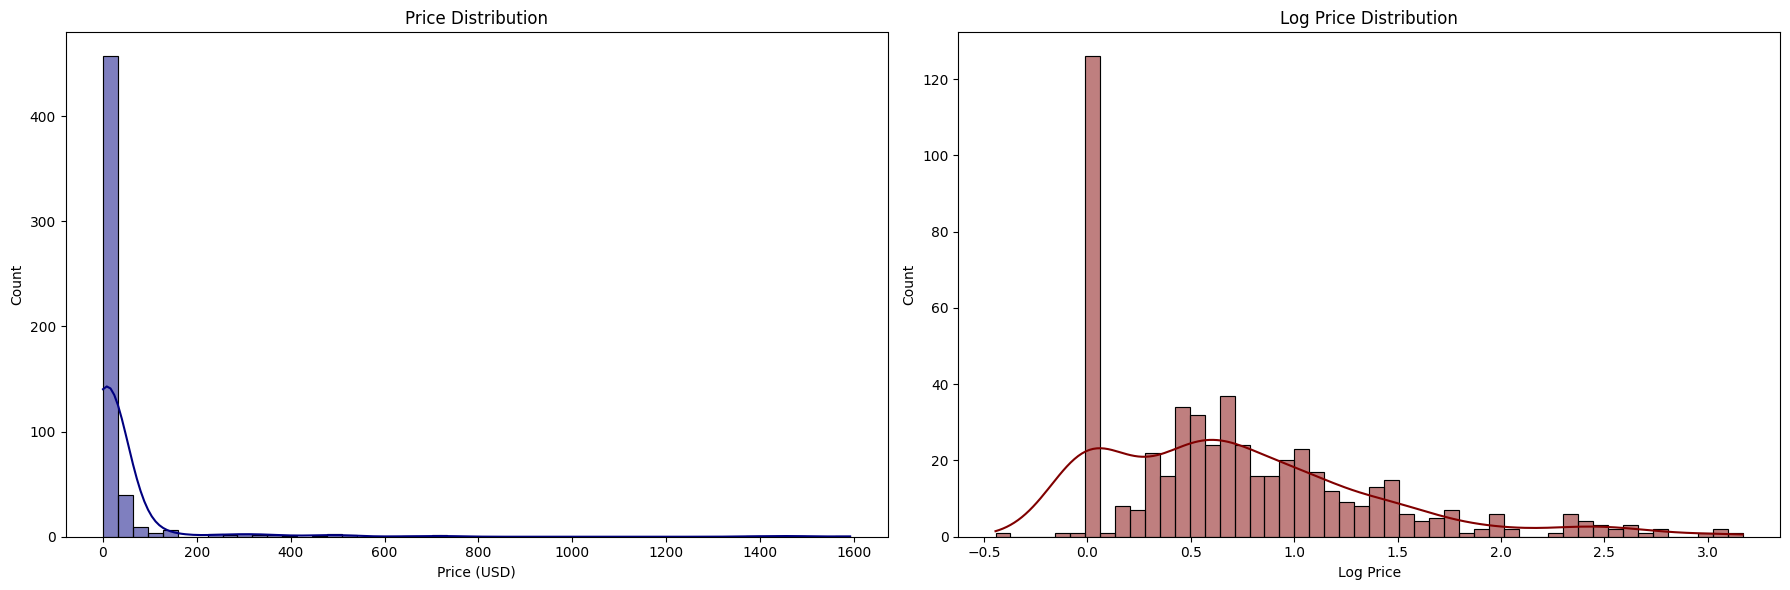

In [7]:
# Price Distribution

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df["price_usd"], bins=50, kde=True, ax=ax[0], color="navy")
ax[0].set_title("Price Distribution")
ax[0].set_xlabel("Price (USD)")

sns.histplot(df["price_log_usd"], bins=50, kde=True, ax=ax[1], color="maroon")
ax[1].set_title("Log Price Distribution")
ax[1].set_xlabel("Log Price")

plt.tight_layout()
plt.show()

### Notes:
The price variable is extremely right skewed. The log transformation is significantly more normally distributed, suiting it better for regression modeling. The price variable shows that a small number of collectibles command a premium and are ultimately statistical outliers when compared to the lower end listings.

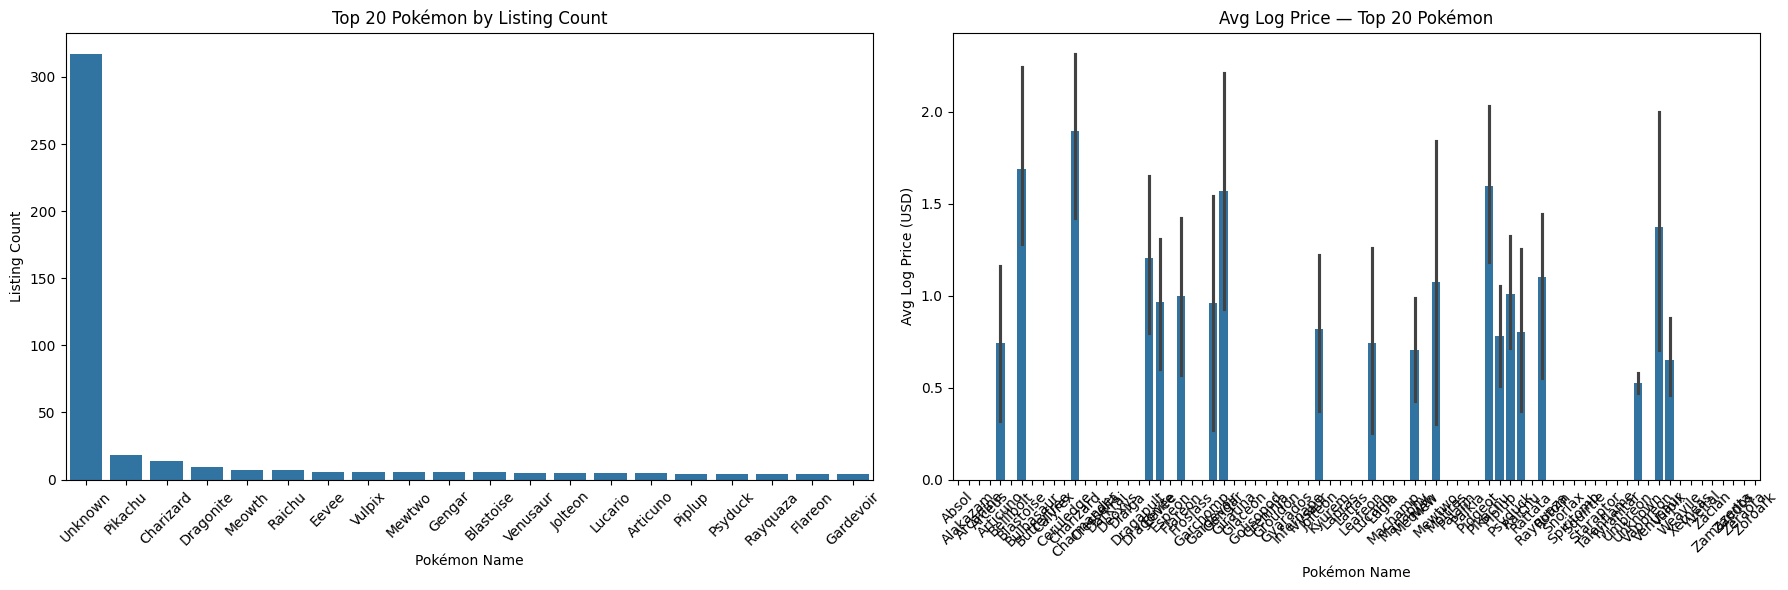

In [15]:
# Top Pokémon by Listing Count
top_20 = df["pokemon_name"].value_counts().head(20)
top_20_names = top_20.index.astype(str).tolist()
top_20_df = df[df["pokemon_name"].astype(str).isin(top_20_names)]

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=top_20.index.astype(str), y=top_20.values, ax=ax[0])
ax[0].set_title("Top 20 Pokémon by Listing Count")
ax[0].set_xlabel("Pokémon Name")
ax[0].set_ylabel("Listing Count")
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(data=top_20_df, x="pokemon_name", y="price_log_usd", ax=ax[1])
ax[1].set_title("Avg Log Price — Top 20 Pokémon")
ax[1].set_xlabel("Pokémon Name")
ax[1].set_ylabel("Avg Log Price (USD)")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Notes:
The majority of listings are uknown pokemon, however, there is a clear trend of generation 1 pokemon being the most common in listings. There is a small group of pokemon that make up the majority of the listed pokemon names. The log price compared to the top 20 in name show that the popular and recognizable characters are commanding the highest prices, such as Charizard and Pikachu.

- potentially check out graded vs ungraded?
- language
- correlation heatmap
- attributes sale price
- set_name
- condition

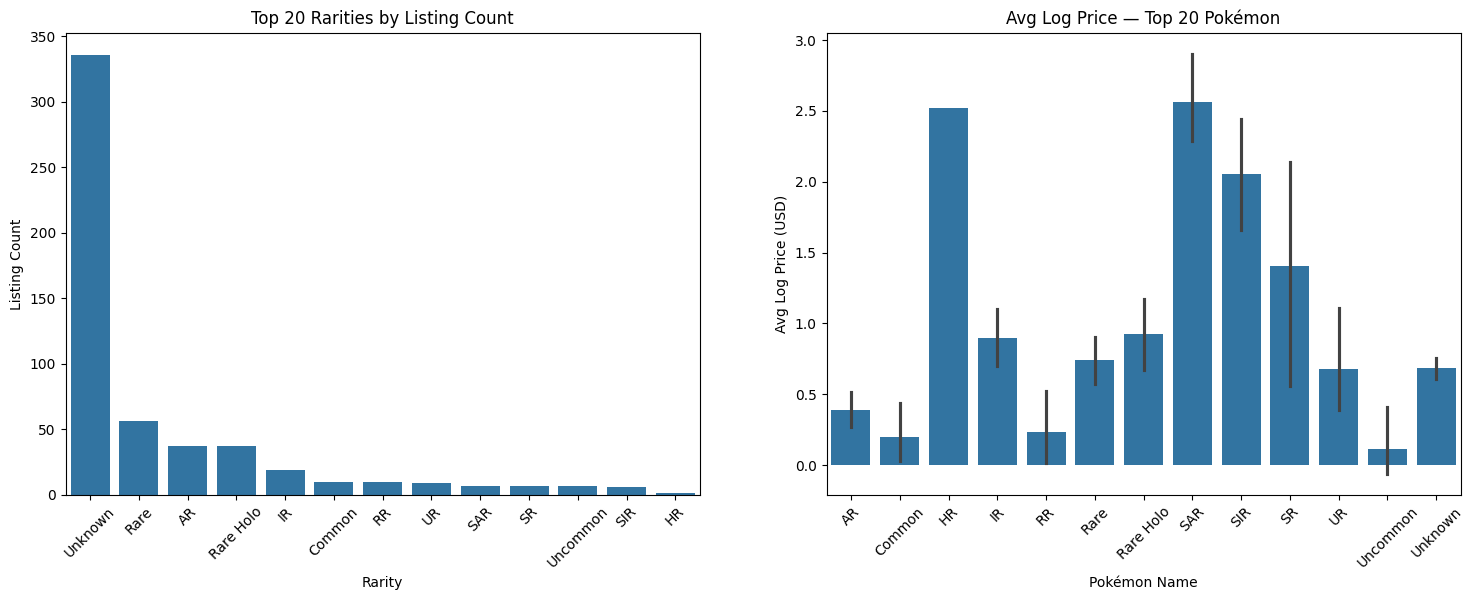

In [16]:
rarity = df['rarity_class'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=rarity.index.astype(str), y=rarity.values, ax=ax[0])
ax[0].set_title("Top 20 Rarities by Listing Count")
ax[0].set_xlabel("Rarity")
ax[0].set_ylabel("Listing Count")
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(data=top_20_df, x="rarity_class", y="price_log_usd", ax=ax[1])
ax[1].set_title("Avg Log Price — Top 20 Pokémon")
ax[1].set_xlabel("Pokémon Name")
ax[1].set_ylabel("Avg Log Price (USD)")
ax[1].tick_params(axis='x', rotation=45)

### Notes:
Some types are rarity command a premium on the market, including SIR (special illustration rare), SAR (special art rare), and HR (Holo rare). Most listings however do not have rarities listed are are unknown.

In [ ]:
# graded cards analysis
# graded vs non graded


# graded by company, grade, etc